# DeepSketch - Sample Training (E2E Vector Style)
This notebook orchestrates end-to-end training on the 500-image sample batch.
It uses the pre-split Kaggle dataset and links the GitHub repository for training execution.

## 1. Check Kaggle GPU & Setup Environment

In [1]:
import os
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch Version: 2.10.0+cu128
CUDA Available: True
GPU: Tesla T4


## 2. Clone the GitHub Repository

In [2]:
!rm -rf stylized-portrait-generation
!git clone https://github.com/supratimcoder1/stylized-portrait-generation.git
%cd stylized-portrait-generation

Cloning into 'stylized-portrait-generation'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 31 (delta 8), reused 25 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 14.69 KiB | 3.67 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/kaggle/working/stylized-portrait-generation


## 3. Install Dependencies

In [3]:
%pip install -r requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 95.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


## 4. Verify Dataset Location

In [4]:
splits = ["train_images", "train_targets", "val_images", "val_targets"]
base_dir = "/kaggle/input/datasets/supratimghosh01/sample-feret/sample_dataset"

print(f"Using dataset base: {base_dir}")
for split in splits:
    path = os.path.join(base_dir, split)
    print(f"{split} found: {len(os.listdir(path))} files")

Using dataset base: /kaggle/input/datasets/supratimghosh01/sample-feret/sample_dataset
train_images found: 450 files
train_targets found: 450 files
val_images found: 50 files
val_targets found: 50 files


## 5. Create Dataset Symlink
Link the Kaggle input dataset into the repo's expected dataset/ location.

In [5]:
!rm -rf dataset
!mkdir -p dataset
!ln -s "$base_dir/train_images" dataset/train_images
!ln -s "$base_dir/train_targets" dataset/train_targets
!ln -s "$base_dir/val_images" dataset/val_images
!ln -s "$base_dir/val_targets" dataset/val_targets

!ls -la dataset/

total 24
drwxr-xr-x 2 root root 4096 Mar 23 19:22 .
drwxr-xr-x 7 root root 4096 Mar 23 19:22 ..
lrwxrwxrwx 1 root root   79 Mar 23 19:22 train_images -> /kaggle/input/datasets/supratimghosh01/sample-feret/sample_dataset/train_images
lrwxrwxrwx 1 root root   80 Mar 23 19:22 train_targets -> /kaggle/input/datasets/supratimghosh01/sample-feret/sample_dataset/train_targets
lrwxrwxrwx 1 root root   77 Mar 23 19:22 val_images -> /kaggle/input/datasets/supratimghosh01/sample-feret/sample_dataset/val_images
lrwxrwxrwx 1 root root   78 Mar 23 19:22 val_targets -> /kaggle/input/datasets/supratimghosh01/sample-feret/sample_dataset/val_targets


## 6. Start Training

In [6]:
!python training/train.py --epochs 100 --batch-size 8 --output-dir /kaggle/working/training_outputs --checkpoint-dir /kaggle/working/checkpoints

Training on cuda
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|█████████████████████████████████████████| 528M/528M [00:02<00:00, 206MB/s]
Epoch 1/100 [Train]: 100%|█| 57/57 [00:17<00:00,  3.27it/s, L1=10.84, Perc=8.49]
Epoch 1 | Train Loss: 25.5594 | Val L1: 0.1584
Saved new best model to /kaggle/working/checkpoints/best_model.pth (Val L1: 0.1584)
Epoch 2/100 [Train]: 100%|██| 57/57 [00:15<00:00,  3.74it/s, L1=8.34, Perc=6.06]
Epoch 2 | Train Loss: 16.2504 | Val L1: 0.0957
Saved new best model to /kaggle/working/checkpoints/best_model.pth (Val L1: 0.0957)
Epoch 3/100 [Train]: 100%|██| 57/57 [00:15<00:00,  3.64it/s, L1=6.37, Perc=6.67]
Epoch 3 | Train Loss: 14.2768 | Val L1: 0.0856
Saved new best model to /kaggle/working/checkpoints/best_model.pth (Val L1: 0.0856)
Epoch 4/100 [Train]: 100%|██| 57/57 [00:16<00:00,  3.53it/s, L1=5.28, Perc=6.29]
Epoch 4 | Train Loss: 13.4902 | Val L1: 0.0917
Epoch 5/100

## 7. Inspect Training Outputs

Showing: /kaggle/working/training_outputs/epoch_99.png


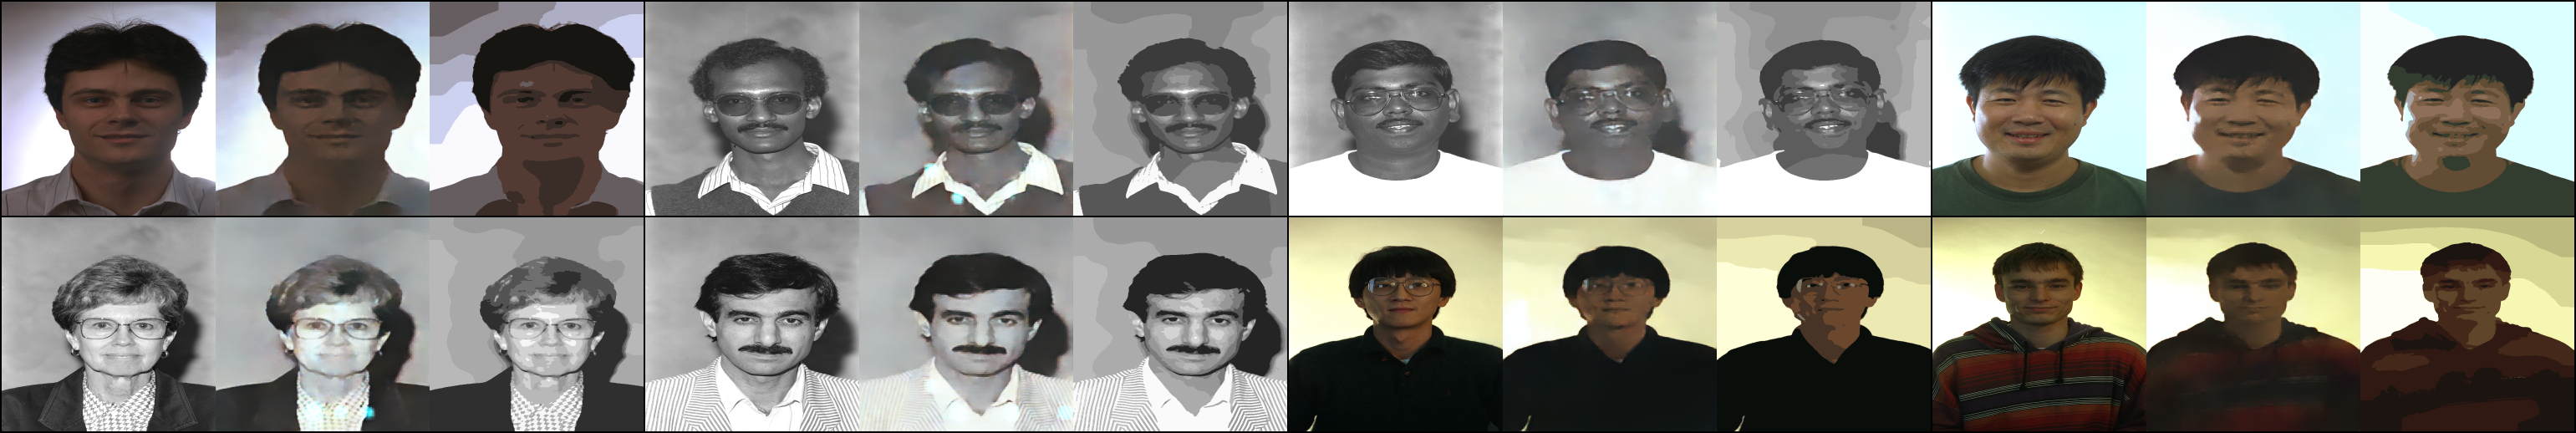

In [7]:
import glob
from IPython.display import display, Image as IPImage

sample_files = sorted(glob.glob("/kaggle/working/training_outputs/epoch_*.png"))
if sample_files:
    latest = sample_files[-1]
    print(f"Showing: {latest}")
    display(IPImage(filename=latest, width=800))
else:
    print("No sample images found - training may not have completed.")

## 8. Download Best Model

In [10]:
!zip -j /kaggle/working/best_model.zip /kaggle/working/checkpoints/best_model.pth
print("Best model zipped to /kaggle/working/best_model.zip")

  adding: best_model.pth (deflated 7%)
Best model zipped to /kaggle/working/best_model.zip
